In [25]:
import json, math, re
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt



# 1) paths

In [27]:
# -------- paths --------
BM25_ROOT = Path("../output/eval_bm25_rm3")
BM25_RUNS_DIR = BM25_ROOT / "runs"

DENSE_ROOT = Path("../output/eval_dense_pubmedbert_small")

SUBSET_PATH = Path("../example/training14b_10pct_sample.json")

TEST_DIR = Path("../bioasq_data/Task13BGoldenEnriched")
TEST_BATCHES = [
    TEST_DIR / "13B1_golden.json",
    TEST_DIR / "13B2_golden.json",
    TEST_DIR / "13B3_golden.json",
    TEST_DIR / "13B4_golden.json",
]

# We'll use BM25_RM3 as the BM25 side
BM25_METHOD_NAME = "BM25_RM3"

# -------- evaluation knobs --------
CAP = 2000
K_MAX_EVAL = 5000
P = 0.95

# Candidate budgets (keep aligned with K_MAX_EVAL unless you want to cap)
KB = K_MAX_EVAL
KD = K_MAX_EVAL

# For backward compatibility in other cells
K_EVAL = K_MAX_EVAL
KS_RECALL = (200, 500, 1000, 2000, 5000)

# RRF grid
K_RRF_LIST = [ 60, 100, 150, 200]
WEIGHTS = [
    (1.0, 1.0),
    (2.0, 1.0),
    (1.0, 2.0),
    (3.0, 1.0),
    (1.0, 3.0),
]

In [50]:
# Output folders
OUTPUT_DIR = Path("../output/eval_hybrid_pubmedbert")
OUTPUT_RUNS_DIR = OUTPUT_DIR / "runs"
OUTPUT_FIG_DIR = OUTPUT_DIR / "figures"


# 2) Gold building + evaluation helpers

In [52]:
def normalize_pmid(x) -> str:
    if x is None:
        return ""
    s = str(x).strip()
    m = re.search(r"/pubmed/(\d+)", s)
    if m:
        return m.group(1)
    if re.fullmatch(r"\d+", s):
        return s
    return s

def build_gold_map_from_questions(questions: list[dict]) -> dict[str, list[str]]:
    gold = {}
    for i, q in enumerate(questions):
        qid = str(q.get("id") or q.get("qid") or i)
        docs = q.get("documents") or []
        pmids = [normalize_pmid(d) for d in docs]
        pmids = [p for p in pmids if p]
        gold[qid] = pmids
    return gold

def runmap_to_tsv(
    run_map: dict[str, list[str]],
    out_path: Path,
    scores: dict[str, dict[str, float]] | None = None,
 ) -> None:
    rows = []
    for qid, docs in run_map.items():
        for i, doc in enumerate(docs, start=1):
            sc = None
            if scores is not None and qid in scores:
                sc = scores[qid].get(doc, None)
            rows.append({"qid": qid, "rank": i, "docno": doc, "score": sc})
    pd.DataFrame(rows).to_csv(out_path, sep="\t", index=False)

def ap_bioasq(gold: set[str], ranked: list[str], k: int = 10) -> float:
    if not gold:
        return 0.0
    hit = 0
    s = 0.0
    for i, doc in enumerate(ranked[:k], start=1):
        if doc in gold:
            hit += 1
            s += hit / i
    # BioASQ MAP@10 uses AP@10, normalized by min(|gold|, 10)
    return s / min(len(gold), k)

def rr_at_k(gold: set[str], ranked: list[str], k: int = 10) -> float:
    for i, doc in enumerate(ranked[:k], start=1):
        if doc in gold:
            return 1.0 / i
    return 0.0

def success_at_k(gold: set[str], ranked: list[str], k: int = 10) -> float:
    return 1.0 if any(doc in gold for doc in ranked[:k]) else 0.0

def recall_at_k(gold: set[str], ranked: list[str], k: int) -> float:
    if not gold:
        return 0.0
    return len(gold.intersection(ranked[:k])) / len(gold)

def recall_at_k_eff(gold: set[str], ranked: list[str], k: int) -> tuple[float, int]:
    k_eff = min(k, len(ranked))
    if not gold or k_eff <= 0:
        return 0.0, k_eff
    return len(gold.intersection(ranked[:k_eff])) / len(gold), k_eff

def evaluate_run(gold_map: dict[str, list[str]], run_map: dict[str, list[str]],
                 ks_recall=KS_RECALL, eps: float = 1e-5) -> dict:
    qids = list(gold_map.keys())
    ap10s, rr10s, succ10s = [], [], []
    recalls = {k: [] for k in ks_recall}

    for qid in qids:
        gold = set(map(str, gold_map.get(qid, [])))
        ranked = list(map(str, run_map.get(qid, [])))

        ap10s.append(ap_bioasq(gold, ranked, k=10))
        rr10s.append(rr_at_k(gold, ranked, k=10))
        succ10s.append(success_at_k(gold, ranked, k=10))

        for k in ks_recall:
            recalls[k].append(recall_at_k(gold, ranked, k=k))

    gmap10 = math.exp(sum(math.log(max(eps, x)) for x in ap10s) / max(1, len(ap10s)))

    summary = {
        "MAP@10": float(np.mean(ap10s)) if ap10s else 0.0,
        "GMAP@10": float(gmap10) if ap10s else 0.0,
        "MRR@10": float(np.mean(rr10s)) if rr10s else 0.0,
        "Success@10": float(np.mean(succ10s)) if succ10s else 0.0,
    }
    for k in ks_recall:
        summary[f"MeanR@{k}"] = float(np.mean(recalls[k])) if recalls[k] else 0.0
    return summary

def make_ks(k_max: int, k0: int = 200, n: int = 4) -> tuple[int, ...]:
    if k_max <= 0:
        return tuple()
    if k_max <= k0:
        return (k_max,)
    ratio = (k_max / k0) ** (1.0 / max(1, n - 1))
    ks = [k0]
    for i in range(1, n - 1):
        ks.append(int(round(k0 * (ratio**i))))
    ks.append(k_max)
    ks = sorted(set(int(k) for k in ks if k > 0))
    if ks[0] != k0:
        ks = [k0] + ks
    if ks[-1] != k_max:
        ks.append(k_max)
    return tuple(sorted(set(ks)))

def evaluate_recall_points(
    gold_map: dict[str, list[str]],
    run_map: dict[str, list[str]],
    ks: tuple[int, ...],
) -> dict:
    out = {}
    qids = list(gold_map.keys())

    for k in ks:
        recalls = []
        shortfalls = []
        keffs = []
        for qid in qids:
            gold = set(map(str, gold_map.get(qid, [])))
            ranked = list(map(str, run_map.get(qid, [])))
            r, k_eff = recall_at_k_eff(gold, ranked, k)
            recalls.append(r)
            keffs.append(k_eff)
            shortfalls.append(1.0 if len(ranked) < k else 0.0)
        out[f"MeanR@{k}"] = float(np.mean(recalls)) if recalls else 0.0
        out[f"ShortfallRate@{k}"] = float(np.mean(shortfalls)) if shortfalls else 0.0
        out[f"MeanKeff@{k}"] = float(np.mean(keffs)) if keffs else 0.0

    return out

def find_k_relative_to_best(metrics: dict, ks_cap: tuple[int, ...], k_best: int, p: float) -> int:
    r_best = metrics.get(f"MeanR@{k_best}", None)
    if r_best is None:
        return max(ks_cap) + 1
    target = p * float(r_best)
    for k in ks_cap:
        if metrics.get(f"MeanR@{k}", -1.0) >= target:
            return int(k)
    return max(ks_cap) + 1



# 3) Load runs (BM25_RM3 TSV + dense parquet)
## 3.1 BM25_RM3 TSV loader

In [29]:
def load_bm25_tsv_run(path: Path) -> pd.DataFrame:
    """
    Expected columns usually include: qid, docno, rank, score
    But we'll handle common variants.
    """
    df = pd.read_csv(path, sep="\t")
    # Normalize column names
    cols = {c.lower(): c for c in df.columns}

    # Identify qid / docno / rank / score columns
    qid_col = cols.get("qid") or cols.get("query_id") or df.columns[0]
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc") or df.columns[1]
    rank_col = cols.get("rank")
    score_col = cols.get("score")

    out = pd.DataFrame({
        "qid": df[qid_col].astype(str),
        "docno": df[doc_col].astype(str).map(normalize_pmid),
    })

    if rank_col:
        out["rank"] = df[rank_col].astype(int)
    else:
        # infer rank by sorting score descending per qid if score exists, else by input order
        if score_col:
            tmp = df.copy()
            tmp["_qid"] = tmp[qid_col].astype(str)
            tmp["_score"] = tmp[score_col].astype(float)
            tmp = tmp.sort_values(["_qid", "_score"], ascending=[True, False])
            tmp["_rank"] = tmp.groupby("_qid").cumcount() + 1
            out = pd.DataFrame({
                "qid": tmp["_qid"],
                "docno": tmp[doc_col].astype(str).map(normalize_pmid),
                "rank": tmp["_rank"].astype(int),
                "score": tmp["_score"].astype(float),
            })
            return out
        else:
            out["rank"] = out.groupby("qid").cumcount() + 1

    if score_col:
        out["score"] = df[score_col].astype(float)
    else:
        out["score"] = np.nan

    # sort
    out = out.sort_values(["qid", "rank"]).reset_index(drop=True)
    return out



# 3.2 Dense parquet loader

In [30]:
def load_dense_parquet_run(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    needed = {"qid", "docno", "rank"}
    if not needed.issubset(df.columns):
        raise ValueError(f"{path} missing columns: {needed - set(df.columns)}")
    out = df.copy()
    out["qid"] = out["qid"].astype(str)
    out["docno"] = out["docno"].astype(str).map(normalize_pmid)
    out["rank"] = out["rank"].astype(int)
    # score exists in your dense parquet
    if "score" in out.columns:
        out["score"] = out["score"].astype(float)
    else:
        out["score"] = np.nan
    out = out.sort_values(["qid", "rank"]).reset_index(drop=True)
    return out



# 4) Fusion methods: RRF
## 4.1 Helpers to cut top-K and to build run_map

In [31]:
def cut_topk(df: pd.DataFrame, k: int) -> pd.DataFrame:
    return df[df["rank"] <= k].copy()

def df_to_run_map(df: pd.DataFrame) -> dict[str, list[str]]:
    run = {}
    for qid, grp in df.groupby("qid", sort=False):
        run[str(qid)] = grp.sort_values("rank")["docno"].astype(str).tolist()
    return run



## 4.2 RRF (optionally weighted)

In [32]:
def fuse_rrf(bm25_df: pd.DataFrame, dense_df: pd.DataFrame,
             k_bm25: int, k_dense: int,
             k_rrf: int = 60,
             w_bm25: float = 1.0, w_dense: float = 1.0,
             k_out: int = K_EVAL) -> dict[str, list[str]]:
    b = cut_topk(bm25_df, k_bm25)
    d = cut_topk(dense_df, k_dense)

    run = {}
    b_grp = {qid: grp for qid, grp in b.groupby("qid", sort=False)}
    d_grp = {qid: grp for qid, grp in d.groupby("qid", sort=False)}
    all_qids = list(dict.fromkeys(list(b_grp.keys()) + list(d_grp.keys())))

    for qid in all_qids:
        scores = {}
        if qid in b_grp:
            for _, row in b_grp[qid].iterrows():
                doc = str(row["docno"])
                r = int(row["rank"])
                scores[doc] = scores.get(doc, 0.0) + (w_bm25 / (k_rrf + r))

        if qid in d_grp:
            for _, row in d_grp[qid].iterrows():
                doc = str(row["docno"])
                r = int(row["rank"])
                scores[doc] = scores.get(doc, 0.0) + (w_dense / (k_rrf + r))

        # sort by fused score desc
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        run[str(qid)] = [doc for doc, _ in ranked[:k_out]]

    return run



# 5) Load gold + runs for each split

In [33]:
def load_questions_from_json(path: Path) -> list[dict]:
    data = json.loads(path.read_text(encoding="utf-8"))
    return data["questions"]

def load_gold_for_split(split: str) -> dict[str, list[str]]:
    if split == "train_subset":
        questions = load_questions_from_json(SUBSET_PATH)
    else:
        fp = TEST_DIR / f"{split}.json"  # not used; we use TEST_BATCHES list
        raise ValueError("Use load_gold_for_test_file for test batches.")
    return build_gold_map_from_questions(questions)

def load_gold_for_test_file(fp: Path) -> dict[str, list[str]]:
    questions = load_questions_from_json(fp)
    return build_gold_map_from_questions(questions)

def bm25_run_path(split: str) -> Path:
    return BM25_RUNS_DIR / f"{BM25_METHOD_NAME}__{split}__top5000.tsv"

def dense_run_path(split: str) -> Path:
    return DENSE_ROOT / f"dense_{split}.parquet"



# 6) Evaluate baseline components + hybrids for one split

In [34]:
def evaluate_split(split: str, bm25_df: pd.DataFrame, dense_df: pd.DataFrame, gold_map: dict[str, list[str]],
                   k_bm25: int, k_dense: int, k_rrf: int = 60,
                   w_bm25: float = 1.0, w_dense: float = 1.0) -> list[dict]:
    out = []

    # Baselines (cut to K_EVAL)
    bm25_run = df_to_run_map(cut_topk(bm25_df, K_EVAL))
    dense_run = df_to_run_map(cut_topk(dense_df, K_EVAL))

    out.append({"method": BM25_METHOD_NAME, "split": split, **evaluate_run(gold_map, bm25_run)})
    out.append({"method": "Dense", "split": split, **evaluate_run(gold_map, dense_run)})

    # RRF only (Union removed)
    rrf_run = fuse_rrf(
        bm25_df,
        dense_df,
        k_bm25=k_bm25,
        k_dense=k_dense,
        k_rrf=k_rrf,
        w_bm25=w_bm25,
        w_dense=w_dense,
        k_out=K_EVAL,
    )
    out.append({
        "method": f"Hybrid-RRF(kb={k_bm25},kd={k_dense},krrf={k_rrf},wb={w_bm25},wd={w_dense})",
        "split": split,
        **evaluate_run(gold_map, rrf_run),
    })

    return out



# 7) Load all splits and run a tuning grid

In [35]:
# Load BM25_RM3 and dense for all splits
splits = ["train_subset"] + [fp.stem for fp in TEST_BATCHES]

bm25_runs = {}
dense_runs = {}
gold_maps = {}

# train_subset gold
EXCLUDE_TEST_QIDS_FROM_TRAIN = True

train_questions_all = load_questions_from_json(SUBSET_PATH)

test_qids = set()
for fp in TEST_BATCHES:
    qs = load_questions_from_json(fp)
    for i, q in enumerate(qs):
        test_qids.add(str(q.get("id") or q.get("qid") or i))

if EXCLUDE_TEST_QIDS_FROM_TRAIN:
    train_questions = [
        q for i, q in enumerate(train_questions_all)
        if str(q.get("id") or q.get("qid") or i) not in test_qids
    ]
else:
    train_questions = train_questions_all

print("train_questions_all:", len(train_questions_all), "train_questions_used:", len(train_questions))
gold_maps["train_subset"] = build_gold_map_from_questions(train_questions)

# test golds
for fp in TEST_BATCHES:
    gold_maps[fp.stem] = load_gold_for_test_file(fp)

train_questions_all: 923 train_questions_used: 583


In [36]:
# Quick sanity-check: BM25_RM3 only (no dense load)
split = "13B1_golden"
bm25_df = load_bm25_tsv_run(bm25_run_path(split))
bm25_run = df_to_run_map(cut_topk(bm25_df, K_EVAL))
print(split, evaluate_run(gold_maps[split], bm25_run))

13B1_golden {'MAP@10': 0.34884360410831, 'GMAP@10': 0.02728784558188759, 'MRR@10': 0.5465499533146593, 'Success@10': 0.788235294117647, 'MeanR@200': 0.6294637338946015, 'MeanR@500': 0.7229471634062333, 'MeanR@1000': 0.7851610099463513, 'MeanR@2000': 0.8389392146021153, 'MeanR@5000': 0.8960677324500657}


In [37]:
# BM25_RM3 recall sanity-check across all splits (focus on deeper recall)
rows = []
for split in splits:
    bm25_df = load_bm25_tsv_run(bm25_run_path(split))
    bm25_run = df_to_run_map(cut_topk(bm25_df, K_EVAL))
    m = evaluate_run(gold_maps[split], bm25_run)
    rows.append({"split": split, **m})

pd.DataFrame(rows)[["split","MAP@10","MeanR@200","MeanR@500","MeanR@1000","MeanR@2000","MeanR@5000"]]

,split,MAP@10,MeanR@200,MeanR@500,MeanR@1000,MeanR@2000,MeanR@5000
0,train_subset,0.241459,0.675101,0.767220,0.817304,0.855935,0.898722
1,13B1_golden,0.348844,0.629464,0.722947,0.785161,0.838939,0.896068
2,13B2_golden,0.345117,0.666853,0.756167,0.805357,0.859822,0.917350
3,13B3_golden,0.303108,0.681145,0.772508,0.825601,0.869313,0.937789
4,13B4_golden,0.218838,0.498454,0.619159,0.708333,0.782250,0.876454


In [38]:

# runs
for split in splits:
    bm25_path = bm25_run_path(split)
    dense_path = dense_run_path(split)

    print("Loading:", split)
    bm25_runs[split] = load_bm25_tsv_run(bm25_path)
    dense_runs[split] = load_dense_parquet_run(dense_path)

print("Loaded splits:", splits)

Loading: train_subset
Loading: 13B1_golden
Loading: 13B2_golden
Loading: 13B3_golden
Loading: 13B4_golden
Loaded splits: ['train_subset', '13B1_golden', '13B2_golden', '13B3_golden', '13B4_golden']


In [39]:
# Option-1 tuning grid (RRF-only, K_p based on relative-to-best)
max_union_upper = KB + KD
k_max_eval_eff = int(min(K_MAX_EVAL, max_union_upper))
cap_eff = int(min(CAP, k_max_eval_eff))

ks_cap = make_ks(cap_eff, k0=200, n=4)
ks_eval = tuple(sorted(set(ks_cap + (k_max_eval_eff,))))

print(f"KB={KB} KD={KD} CAP={CAP} K_MAX_EVAL={K_MAX_EVAL} => cap_eff={cap_eff} k_max_eval_eff={k_max_eval_eff}")
print("ks_cap:", ks_cap)
print("ks_eval:", ks_eval)

rows = []
test_splits = [fp.stem for fp in TEST_BATCHES]

for (w_bm25, w_dense) in WEIGHTS:
    for k_rrf in K_RRF_LIST:
        for split in splits:
            gold_map = gold_maps[split]

            fused = fuse_rrf(
                bm25_df=bm25_runs[split],
                dense_df=dense_runs[split],
                k_bm25=KB,
                k_dense=KD,
                k_rrf=k_rrf,
                w_bm25=w_bm25,
                w_dense=w_dense,
                k_out=k_max_eval_eff,
            )

            metrics = evaluate_recall_points(gold_map, fused, ks=ks_eval)
            k_rec = find_k_relative_to_best(metrics, ks_cap=ks_cap, k_best=k_max_eval_eff, p=P)

            row = {
                "split": split,
                "k_rrf": int(k_rrf),
                "w_bm25": float(w_bm25),
                "w_dense": float(w_dense),
                "KB": int(KB),
                "KD": int(KD),
                "CAP": int(CAP),
                "CAP_eff": int(cap_eff),
                "K_MAX_EVAL": int(K_MAX_EVAL),
                "K_MAX_EVAL_eff": int(k_max_eval_eff),
                "P": float(P),
                "K_rec": int(k_rec),
                f"ShortfallRate@{cap_eff}": metrics.get(f"ShortfallRate@{cap_eff}", np.nan),
                f"MeanKeff@{cap_eff}": metrics.get(f"MeanKeff@{cap_eff}", np.nan),
                f"MeanR@{cap_eff}": metrics.get(f"MeanR@{cap_eff}", np.nan),
                f"MeanR@{k_max_eval_eff}": metrics.get(f"MeanR@{k_max_eval_eff}", np.nan),
            }
            for k in ks_eval:
                row[f"MeanR@{k}"] = metrics.get(f"MeanR@{k}", np.nan)
            rows.append(row)

results_df = pd.DataFrame(rows)
results_df.head()

KB=5000 KD=5000 CAP=2000 K_MAX_EVAL=5000 => cap_eff=2000 k_max_eval_eff=5000
ks_cap: (200, 431, 928, 2000)
ks_eval: (200, 431, 928, 2000, 5000)


,split,k_rrf,w_bm25,w_dense,KB,KD,CAP,CAP_eff,K_MAX_EVAL,K_MAX_EVAL_eff,P,K_rec,ShortfallRate@2000,MeanKeff@2000,MeanR@2000,MeanR@5000,MeanR@200,MeanR@431,MeanR@928
0,train_subset,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.870776,0.917569,0.655802,0.745614,0.818175
1,13B1_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.869032,0.915526,0.654912,0.737564,0.809618
2,13B2_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.875701,0.934504,0.671956,0.748431,0.820200
3,13B3_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.884921,0.938759,0.671287,0.756700,0.819786
4,13B4_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.832233,0.909816,0.511583,0.619114,0.731571


In [40]:
results_df

,split,k_rrf,w_bm25,w_dense,KB,KD,CAP,CAP_eff,K_MAX_EVAL,K_MAX_EVAL_eff,P,K_rec,ShortfallRate@2000,MeanKeff@2000,MeanR@2000,MeanR@5000,MeanR@200,MeanR@431,MeanR@928
0,train_subset,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.870776,0.917569,0.655802,0.745614,0.818175
1,13B1_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.869032,0.915526,0.654912,0.737564,0.809618
2,13B2_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.875701,0.934504,0.671956,0.748431,0.820200
3,13B3_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.884921,0.938759,0.671287,0.756700,0.819786
4,13B4_golden,60,1.0,1.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.832233,0.909816,0.511583,0.619114,0.731571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,train_subset,200,1.0,3.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.845881,0.904891,0.415537,0.578822,0.765550
96,13B1_golden,200,1.0,3.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.854968,0.917677,0.516177,0.671093,0.790028
97,13B2_golden,200,1.0,3.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.863328,0.917994,0.415800,0.608735,0.789185
98,13B3_golden,200,1.0,3.0,5000,5000,2000,2000,5000,5000,0.95,2001,0.0,2000.0,0.862319,0.923495,0.427246,0.598696,0.790332


# 8) Pick best config (relative-to-best recall)

In [44]:
test_splits = [fp.stem for fp in TEST_BATCHES]

def rank_option1(df: pd.DataFrame) -> pd.DataFrame:
    d = df[df["split"].isin(test_splits)].copy()
    # Treat CAP+1 as CAP for aggregation to avoid fractional K_rec from averaging.
    d["K_rec_clipped"] = d["K_rec"].clip(upper=cap_eff)

    agg_cols = {
        "K_rec_clipped": "mean",
        f"MeanR@{cap_eff}": "mean",
        f"MeanR@{k_max_eval_eff}": "mean",
        f"ShortfallRate@{cap_eff}": "mean",
        f"MeanKeff@{cap_eff}": "mean",
    }

    grp = d.groupby(["k_rrf", "w_bm25", "w_dense"], as_index=False).agg(agg_cols)
    grp = grp.rename(columns={"K_rec_clipped": "K_rec"})

    grp = grp.sort_values(
        by=["K_rec", f"MeanR@{cap_eff}", f"ShortfallRate@{cap_eff}"],
        ascending=[True, False, True],
    ).reset_index(drop=True)
    return grp

ranked = rank_option1(results_df)
ranked

,k_rrf,w_bm25,w_dense,K_rec,MeanR@2000,MeanR@5000,ShortfallRate@2000,MeanKeff@2000
0,100,2.0,1.0,2000.0,0.867623,0.924574,0.0,2000.0
1,200,2.0,1.0,2000.0,0.867351,0.924826,0.0,2000.0
2,150,2.0,1.0,2000.0,0.867276,0.924702,0.0,2000.0
3,60,2.0,1.0,2000.0,0.866978,0.924618,0.0,2000.0
4,200,1.0,1.0,2000.0,0.865914,0.924651,0.0,2000.0
5,150,1.0,1.0,2000.0,0.865649,0.924651,0.0,2000.0
6,100,1.0,1.0,2000.0,0.865622,0.924651,0.0,2000.0
7,60,1.0,1.0,2000.0,0.865472,0.924651,0.0,2000.0
8,60,3.0,1.0,2000.0,0.864519,0.923750,0.0,2000.0
9,200,3.0,1.0,2000.0,0.864283,0.923663,0.0,2000.0


In [45]:
best = ranked.iloc[0].to_dict() if len(ranked) else {}
best

{'k_rrf': 100.0,
 'w_bm25': 2.0,
 'w_dense': 1.0,
 'K_rec': 2000.0,
 'MeanR@2000': 0.8676231652344983,
 'MeanR@5000': 0.9245744199797556,
 'ShortfallRate@2000': 0.0,
 'MeanKeff@2000': 2000.0}

In [53]:
# 8.1) Save results + best runs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_RUNS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(OUTPUT_DIR / "results_all.csv", index=False)
ranked.to_csv(OUTPUT_DIR / "ranked_test_avg.csv", index=False)

best_cfg = ranked.iloc[0].to_dict() if len(ranked) else {}
if best_cfg:
    (OUTPUT_DIR / "best_config.json").write_text(json.dumps(best_cfg, indent=2), encoding="utf-8")

for split in splits:
    best_row = results_df[
        (results_df["split"] == split)
        & (results_df["k_rrf"] == int(best_cfg["k_rrf"]))
        & (results_df["w_bm25"] == float(best_cfg["w_bm25"]))
        & (results_df["w_dense"] == float(best_cfg["w_dense"]))
    ].iloc[0]

    k_out = int(best_row["K_rec"]) if int(best_row["K_rec"]) <= CAP else CAP
    best_run = fuse_rrf(
        bm25_df=bm25_runs[split],
        dense_df=dense_runs[split],
        k_bm25=k_out,
        k_dense=k_out,
        k_rrf=int(best_row["k_rrf"]),
        w_bm25=float(best_row["w_bm25"]),
        w_dense=float(best_row["w_dense"]),
        k_out=k_out,
    )
    runmap_to_tsv(best_run, OUTPUT_RUNS_DIR / f"best_rrf_{split}_top{k_out}.tsv")

# 9) plots

In [54]:
def plot_option1_curve(row, ks_cap, cap, k_max_eval, p=0.95, title="", save_path: Path | None = None):
    """
    row: one aggregated row for a config+split (has MeanR@{k} columns)
    ks_cap: list of K values up to cap, e.g. [200, 300, 500, 800, 1000, 1500, 2000]
    """
    ks = list(ks_cap) + [k_max_eval]
    ys = [row.get(f"MeanR@{k}", np.nan) for k in ks]

    rmax = row.get(f"MeanR@{k_max_eval}", np.nan)
    target = p * rmax if np.isfinite(rmax) else np.nan
    k_rec = row.get("K_rec", np.nan)  # computed by your script

    plt.figure()
    plt.plot(ks, ys, marker="o")
    plt.xlabel("K")
    plt.ylabel("Mean Recall@K")
    plt.title(title or "Option-1 recall curve")

    if np.isfinite(target):
        plt.axhline(target, linestyle="--", label=f"p·Rmax (p={p})")
    if np.isfinite(k_rec) and k_rec <= cap:
        plt.axvline(k_rec, linestyle=":", label=f"K_rec={int(k_rec)}")

    plt.legend(fontsize="small")
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [55]:
def plot_scatter_krec(df_cfg, cap, k_max_eval, title="", save_path: Path | None = None):
    d = df_cfg.copy()
    # configs that never reach p*Rmax within cap have K_rec = cap+1 in the script
    d["K_rec_plot"] = d["K_rec"].clip(upper=cap+50)

    plt.figure()
    plt.scatter(d["K_rec_plot"], d[f"MeanR@{cap}"], s=40)
    plt.xlabel("K_rec (clipped)")
    plt.ylabel(f"MeanR@{cap}")
    plt.title(title or "Configs: K_rec vs MeanR@CAP")
    plt.ticklabel_format(axis="x", style="plain", useOffset=False)
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [56]:
def plot_shortfall(df_cfg, cap, topn=10, save_path: Path | None = None):
    d = df_cfg.sort_values(["K_rec", f"MeanR@{cap}"], ascending=[True, False]).head(topn)
    plt.figure()
    plt.bar(range(len(d)), d[f"ShortfallRate@{cap}"])
    plt.xticks(range(len(d)), [f"{int(r.k_rrf)},{r.w_bm25}/{r.w_dense}" for r in d.itertuples()],
               rotation=45, ha="right")
    plt.ylabel(f"ShortfallRate@{cap}")
    plt.title("Top configs: shortfall rate")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()



In [57]:
def plot_keff(df_cfg, cap, topn=10, save_path: Path | None = None):
    d = df_cfg.sort_values(["K_rec", f"MeanR@{cap}"], ascending=[True, False]).head(topn)
    plt.figure()
    plt.bar(range(len(d)), d[f"MeanKeff@{cap}"])
    plt.xticks(range(len(d)), [f"{int(r.k_rrf)},{r.w_bm25}/{r.w_dense}" for r in d.itertuples()],
               rotation=45, ha="right")
    plt.ylabel(f"MeanKeff@{cap}")
    plt.title("Top configs: mean effective depth")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()



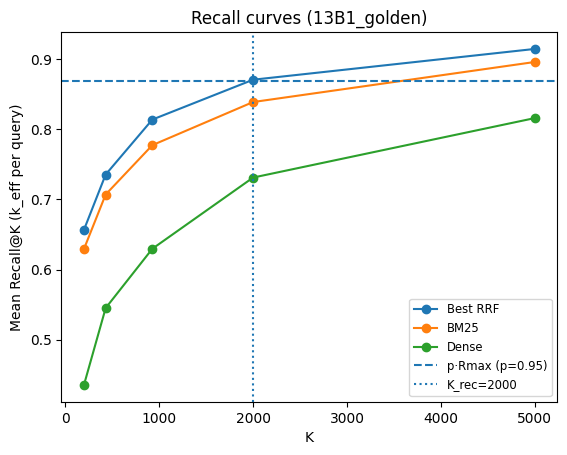

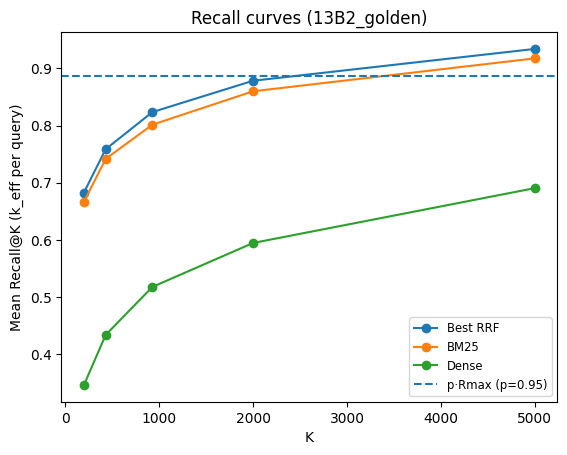

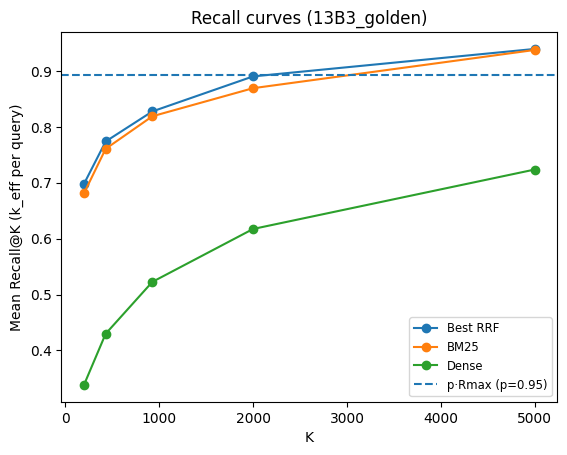

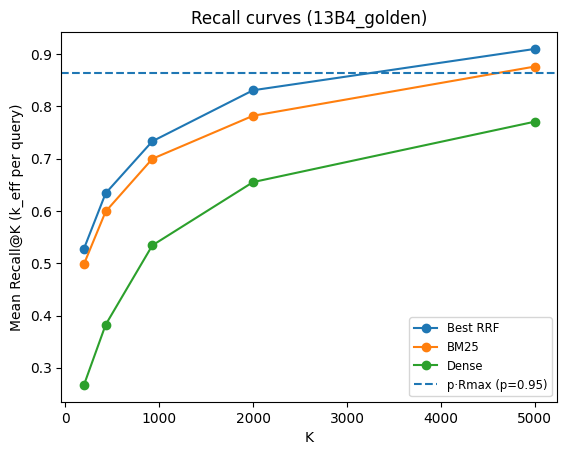

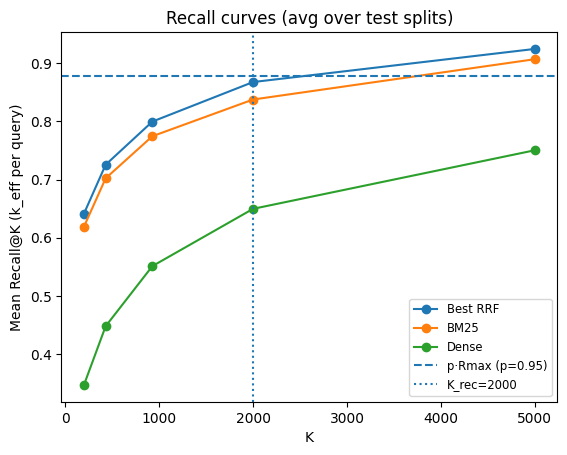

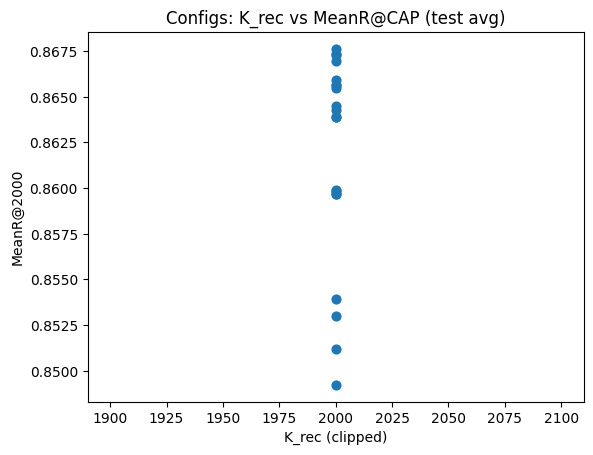

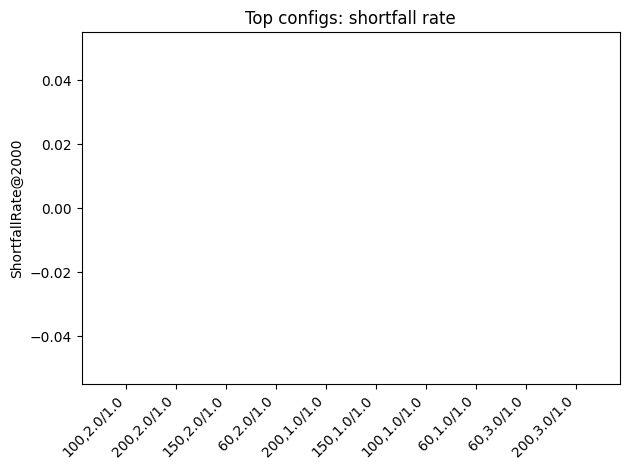

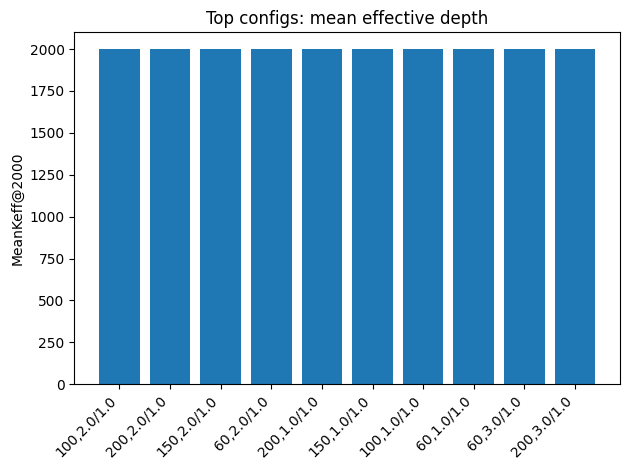

In [58]:
# ---- Meaningful plots for Option-1 (with BM25/Dense) ----
if len(ranked) == 0:
    raise ValueError("No ranked configs; run the grid cell first.")

best_cfg = ranked.iloc[0]
best_krrf = int(best_cfg["k_rrf"])
best_wb = float(best_cfg["w_bm25"])
best_wd = float(best_cfg["w_dense"])

def baseline_metrics_for_split(split: str, method: str) -> dict:
    if method == "BM25":
        run = df_to_run_map(cut_topk(bm25_runs[split], k_max_eval_eff))
    elif method == "Dense":
        run = df_to_run_map(cut_topk(dense_runs[split], k_max_eval_eff))
    else:
        raise ValueError("method must be BM25 or Dense")
    return evaluate_recall_points(gold_maps[split], run, ks=ks_eval)

# 1) Per-split recall curves: best config vs BM25 vs Dense
for split in test_splits:
    best_row = results_df[
        (results_df["split"] == split)
        & (results_df["k_rrf"] == best_krrf)
        & (results_df["w_bm25"] == best_wb)
        & (results_df["w_dense"] == best_wd)
    ].iloc[0]

    bm25_metrics = baseline_metrics_for_split(split, "BM25")
    dense_metrics = baseline_metrics_for_split(split, "Dense")

    ks = list(ks_cap) + [k_max_eval_eff]
    plt.figure()
    plt.plot(ks, [best_row.get(f"MeanR@{k}", np.nan) for k in ks], marker="o", label="Best RRF")
    plt.plot(ks, [bm25_metrics.get(f"MeanR@{k}", np.nan) for k in ks], marker="o", label="BM25")
    plt.plot(ks, [dense_metrics.get(f"MeanR@{k}", np.nan) for k in ks], marker="o", label="Dense")

    rmax = best_row.get(f"MeanR@{k_max_eval_eff}", np.nan)
    target = P * rmax if np.isfinite(rmax) else np.nan
    k_rec = best_row.get("K_rec", np.nan)
    if np.isfinite(target):
        plt.axhline(target, linestyle="--", label=f"p·Rmax (p={P})")
    if np.isfinite(k_rec) and k_rec <= cap_eff:
        plt.axvline(k_rec, linestyle=":", label=f"K_rec={int(k_rec)}")

    plt.xlabel("K")
    plt.ylabel("Mean Recall@K (k_eff per query)")
    plt.title(f"Recall curves ({split})")
    plt.legend(fontsize="small")
    plt.savefig(OUTPUT_FIG_DIR / f"recall_curve_{split}.png", dpi=150, bbox_inches="tight")
    plt.show()

# 2) Average recall curve across test splits (best config vs BM25 vs Dense)
mean_best = {"K_rec": best_cfg["K_rec"]}
mean_bm25 = {}
mean_dense = {}
for k in ks_eval:
    mean_best[f"MeanR@{k}"] = (
        results_df[
            (results_df["split"].isin(test_splits))
            & (results_df["k_rrf"] == best_krrf)
            & (results_df["w_bm25"] == best_wb)
            & (results_df["w_dense"] == best_wd)
        ][f"MeanR@{k}"]
        .mean()
    )
    mean_bm25[f"MeanR@{k}"] = np.mean([baseline_metrics_for_split(s, "BM25").get(f"MeanR@{k}", np.nan) for s in test_splits])
    mean_dense[f"MeanR@{k}"] = np.mean([baseline_metrics_for_split(s, "Dense").get(f"MeanR@{k}", np.nan) for s in test_splits])

ks = list(ks_cap) + [k_max_eval_eff]
plt.figure()
plt.plot(ks, [mean_best.get(f"MeanR@{k}", np.nan) for k in ks], marker="o", label="Best RRF")
plt.plot(ks, [mean_bm25.get(f"MeanR@{k}", np.nan) for k in ks], marker="o", label="BM25")
plt.plot(ks, [mean_dense.get(f"MeanR@{k}", np.nan) for k in ks], marker="o", label="Dense")

rmax = mean_best.get(f"MeanR@{k_max_eval_eff}", np.nan)
target = P * rmax if np.isfinite(rmax) else np.nan
k_rec = mean_best.get("K_rec", np.nan)
if np.isfinite(target):
    plt.axhline(target, linestyle="--", label=f"p·Rmax (p={P})")
if np.isfinite(k_rec) and k_rec <= cap_eff:
    plt.axvline(k_rec, linestyle=":", label=f"K_rec={int(k_rec)}")

plt.xlabel("K")
plt.ylabel("Mean Recall@K (k_eff per query)")
plt.title("Recall curves (avg over test splits)")
plt.legend(fontsize="small")
plt.savefig(OUTPUT_FIG_DIR / "recall_curve_test_avg.png", dpi=150, bbox_inches="tight")
plt.show()

# 3) Config-level scatter + diagnostics on test splits
plot_scatter_krec(ranked, cap=cap_eff, k_max_eval=k_max_eval_eff, title="Configs: K_rec vs MeanR@CAP (test avg)", save_path=OUTPUT_FIG_DIR / "krec_vs_recall.png")
plot_shortfall(ranked, cap=cap_eff, topn=10, save_path=OUTPUT_FIG_DIR / "shortfall_top10.png")
plot_keff(ranked, cap=cap_eff, topn=10, save_path=OUTPUT_FIG_DIR / "keff_top10.png")

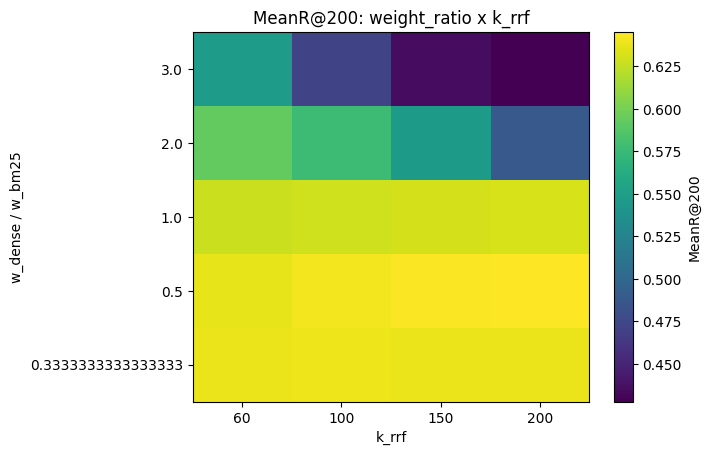

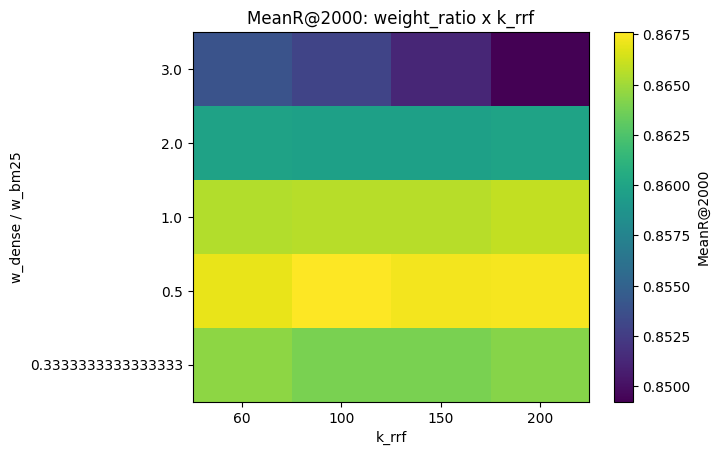

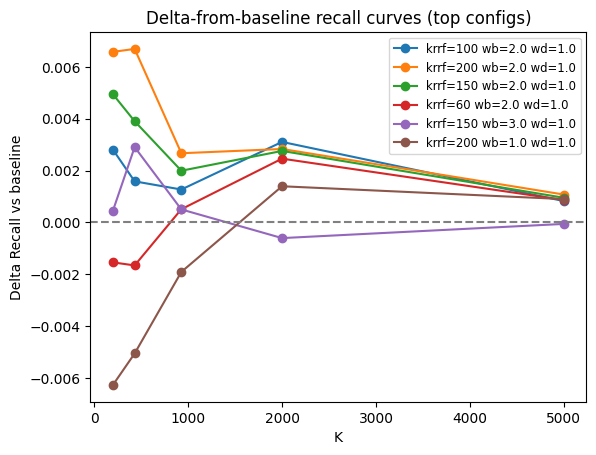

In [59]:
# 10) Param-sensitivity plots (no save)
df_test = results_df[results_df["split"].isin(test_splits)].copy()
recall_cols = [c for c in df_test.columns if c.startswith("MeanR@")]
recall_cols = sorted(recall_cols, key=lambda c: int(c.split("@")[1]))

agg = df_test.groupby(["k_rrf", "w_bm25", "w_dense"], as_index=False).agg(
    {**{c: "mean" for c in recall_cols}, "K_rec": "mean"}
)
agg["weight_ratio"] = agg["w_dense"] / agg["w_bm25"]
agg = agg.sort_values(["weight_ratio", "k_rrf"]).reset_index(drop=True)

# 10.1) Small-multiples heatmaps: metric x (weight_ratio, k_rrf)
heat_metrics = ["MeanR@200", f"MeanR@{cap_eff}"]
heat_metrics = [m for m in heat_metrics if m in agg.columns]
for metric in heat_metrics:
    piv = agg.pivot_table(index="weight_ratio", columns="k_rrf", values=metric, aggfunc="mean")
    plt.figure()
    plt.imshow(piv.values, aspect="auto", origin="lower")
    plt.colorbar(label=metric)
    plt.xticks(range(len(piv.columns)), piv.columns.astype(str))
    plt.yticks(range(len(piv.index)), [str(x) for x in piv.index])
    plt.xlabel("k_rrf")
    plt.ylabel("w_dense / w_bm25")
    plt.title(f"{metric}: weight_ratio x k_rrf")
    plt.show()

# 10.2) Delta-from-baseline curves per config
baseline = agg[(agg["w_bm25"] == 1.0) & (agg["w_dense"] == 1.0) & (agg["k_rrf"] == 30)]
if len(baseline) == 0:
    baseline = agg.iloc[[0]]
baseline = baseline.iloc[0]
top_configs = agg.sort_values(["K_rec", f"MeanR@{cap_eff}"], ascending=[True, False]).head(6)
ks = [int(c.split("@")[1]) for c in recall_cols]
plt.figure()
for _, row in top_configs.iterrows():
    deltas = [row[f"MeanR@{k}"] - baseline[f"MeanR@{k}"] for k in ks]
    label = f"krrf={int(row.k_rrf)} wb={row.w_bm25} wd={row.w_dense}"
    plt.plot(ks, deltas, marker="o", label=label)
plt.axhline(0.0, linestyle="--", color="gray")
plt.xlabel("K")
plt.ylabel("Delta Recall vs baseline")
plt.title("Delta-from-baseline recall curves (top configs)")
plt.legend(fontsize="small")
plt.show()
